### K-Means clustering with Synthetic data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from ipywidgets import interact, IntSlider, Button, interactive_output
from pandas import DataFrame
import pandas as pd


In [2]:
# Create some synthetic data
# X, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.0, random_state=42)
X = pd.read_csv("data/clustering_segmentation_Amz_Customers.csv")
print("Sample size=" + str(X.shape))
print("Sample size=" + str(len(X)))
display(DataFrame(X))

# plt.scatter(X[:,0], X[:,1], s=30)
# plt.title("Sample Data for Clustering")
# plt.show()

Sample size=(20, 4)
Sample size=20


,Annual_Income_k,Spending_Score_1_100,Age,Frequency_of_Purchase
0,107,15,23,16
1,56,92,32,13
2,40,98,60,42
3,113,66,54,30
4,64,32,50,19
5,39,87,25,17
6,38,63,61,19
7,27,86,61,28
8,74,51,22,26
9,21,25,56,37


In [43]:
def plot_kmeans(k, X):
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=200)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    plt.figure(figsize=(6,6))
    # use .iloc to specify column by the index (instead of the name)
    # plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels, cmap='viridis', s=40, alpha=0.7)
    plt.scatter(centers[:,0], centers[:,1], c='red', marker='X', s=200, label='Centroids')

    # Alt: specify the column-name
    # plt.scatter(
    #     X['Spending_Score_1_100'].values,
    #     X['Frequency_of_Purchase'].values,
    #     c=labels, cmap='viridis', s=40, alpha=0.7)
    # plt.scatter(centers[:,1], centers[:,3], c='red', marker='X', s=200, label='Centroids')

    plt.title(f'K-Means Clustering (K={k})')
    plt.legend()
    plt.show()

array([107,  56,  40, 113,  64,  39,  38,  27,  74,  21,  71,  50,  59,
        34,  79,  22,  30,  28,  90, 101])

0     107
1      56
2      40
3     113
4      64
5      39
6      38
7      27
8      74
9      21
10     71
11     50
12     59
13     34
14     79
15     22
16     30
17     28
18     90
19    101
Name: Annual_Income_k, dtype: int64

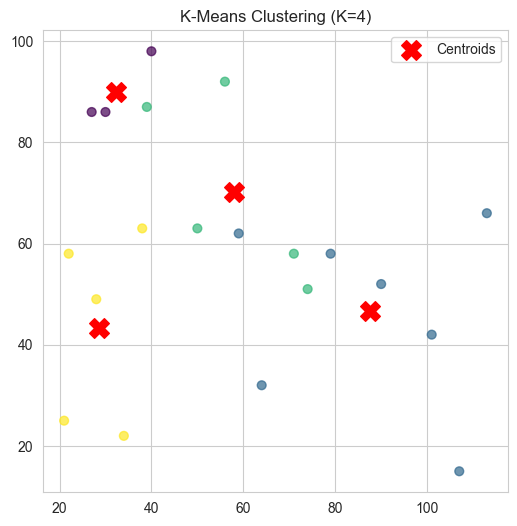

In [44]:
display(X[X.columns[0]].values)
display(X.iloc[:,0])

plot_kmeans(4, X)

In [5]:
def kmeans_iteration_demo(iterations=5, k=4):
    np.random.seed(42)

    centers = X[np.random.choice(len(X), k, replace=True)]

    for i in range(iterations):
        # Assign points
        labels = np.argmin(np.linalg.norm(X[:, None] - centers[None, :], axis=2), axis=1)
        # Plot clusters
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, alpha=0.6)
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200)
        plt.title(f"Iteration {i + 1}")
        plt.show()

        # Update centroids
        new_centers = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers


interact(kmeans_iteration_demo,
         iterations=IntSlider(min=1, max=20, step=1, value=10),
         k=IntSlider(min=2, max=6, step=1, value=4),
         )

interactive(children=(IntSlider(value=10, description='iterations', max=20, min=1), IntSlider(value=4, descrip…

<function __main__.kmeans_iteration_demo(iterations=5, k=4)>

### Elbow Plot
Elbow Plot tells you the average cluster-centroid distance (WCSS) from each data-point. Lower the WCSS value -> Higher the clustering fit.



In [6]:
# Calculate WCSS for various values of K (1 to 10)
def plot_elbow(df):
    wcss = []
    k_range = range(1, 11)

    for k in k_range:
        # Initialize KMeans with k clusters, using k-means++ for smarter initialization
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

        # Fit the model to the data
        # NOTE: Replace 'X' with the actual variable name of your processed data (e.g., df or X_scaled)
        kmeans.fit(df)

        # Append the WCSS (inertia) to the list
        wcss.append(kmeans.inertia_)

    # Plot the Elbow diagram
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
    plt.title('Elbow Method For Optimal K', fontsize=14)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('WCSS', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

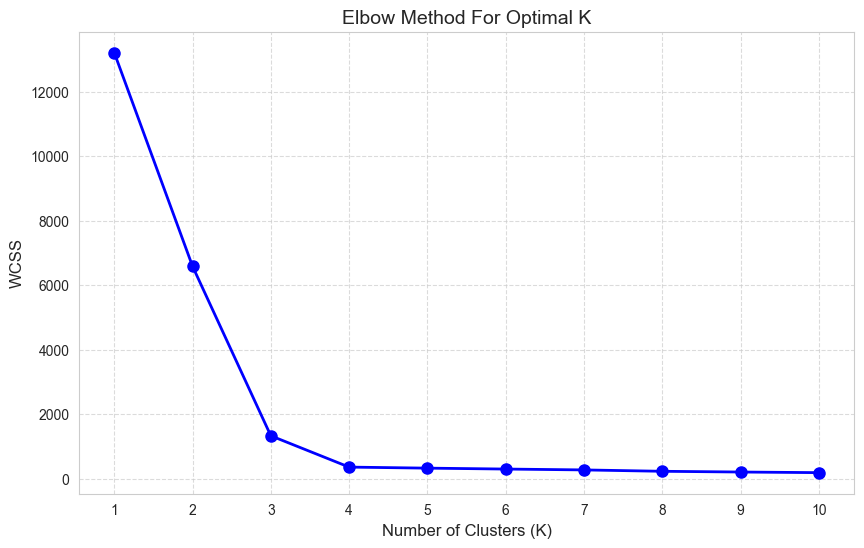

In [7]:
plot_elbow(X)